# Verificación de supuestos

In [1]:
import sys
print(sys.executable)

C:\Users\danie\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe


In [15]:
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\danie\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import sys
import joblib
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import make_scorer

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    REPO_ROOT = CURRENT_DIR.parent
else:
    REPO_ROOT = CURRENT_DIR

MODELS_PATH = REPO_ROOT / "models"
RESULTS_PATH = REPO_ROOT / "results"
DATASET_PATH = REPO_ROOT / "data" / "processed" / "dataset_modelo.csv"

sys.path.insert(0, str(MODELS_PATH))

from _experiment_utils import prepare_features, split_train_val_test

print("Raíz del repositorio:", REPO_ROOT)
print("Dataset encontrado:", DATASET_PATH.exists())
print("Carpeta models encontrada:", MODELS_PATH.exists())

Raíz del repositorio: c:\Users\danie\OneDrive\Documentos\Maestría_MIAD\4 Semestre\Proyecto aplicado en analítica de datos\agroindice-cafe
Dataset encontrado: True
Carpeta models encontrada: True


In [3]:
df = pd.read_csv(
    DATASET_PATH,
    parse_dates=["window_start", "window_end"])

train_val, test_final = split_train_val_test(
    df,
    fecha_col="window_start",
    frac_test_final=0.15)

print("Dimensiones del dataset:", df.shape)

print(
    "Periodo de entrenamiento y validación:",
    train_val["window_start"].min(),
    "a",
    train_val["window_start"].max())

print(
    "Periodo reservado para prueba final:",
    test_final["window_start"].min(),
    "a",
    test_final["window_start"].max())

print("Filas de entrenamiento y validación:", len(train_val))
print("Filas reservadas para prueba final:", len(test_final))

split_train_val_test (fecha_col='window_start', frac_test_final=0.15):
  train_val:  2000-03-21 00:00:00 -> 2022-07-28 00:00:00  (1030 filas)
  test_final: 2022-08-13 00:00:00 -> 2026-07-12 00:00:00  (182 filas)
Dimensiones del dataset: (1212, 48)
Periodo de entrenamiento y validación: 2000-03-21 00:00:00 a 2022-07-28 00:00:00
Periodo reservado para prueba final: 2022-08-13 00:00:00 a 2026-07-12 00:00:00
Filas de entrenamiento y validación: 1030
Filas reservadas para prueba final: 182


In [4]:
X_completo, y_ndvi = prepare_features(train_val, target_col="ndvi")

# Variables que no pertenecen al escenario seleccionado
columnas_excluir = ["lai_high_lag0", "lai_high_lag1", "lai_high_lag2", "evi_lag_1year", "evi_lag1w"]

columnas_excluir = [
columna
    for columna in columnas_excluir
    if columna in X_completo.columns]

X_ndvi = X_completo.drop(columns=columnas_excluir).reset_index(drop=True)

y_ndvi = y_ndvi.reset_index(drop=True)

print("Objetivo: NDVI")
print("Número de observaciones:", len(y_ndvi))
print("Número de variables:", X_ndvi.shape[1])
print("Variables excluidas:", columnas_excluir)

assert X_ndvi.shape[1] == 39, (f"Se esperaban 39 variables, pero se encontraron {X_ndvi.shape[1]}")

print("\nValores faltantes por variable:")
display(
    X_ndvi.isna()
    .sum()
    .sort_values(ascending=False)
    .head(10))

Objetivo: NDVI
Número de observaciones: 1030
Número de variables: 39
Variables excluidas: ['lai_high_lag0', 'lai_high_lag1', 'lai_high_lag2', 'evi_lag_1year', 'evi_lag1w']

Valores faltantes por variable:


deficit_hidrico_trend2y    44
ndvi_lag_1year             42
et_mm_lag1                  2
dewpoint_c_lag0             0
precip_mm_lag0              0
pet_mm_lag0                 0
tmean_c_lag0                0
soil_moist_layer3_lag0      0
soil_moist_layer2_lag0      0
soil_moist_layer1_lag0      0
dtype: int64

In [5]:
fechas_train_val = pd.to_datetime(train_val["window_start"]).reset_index(drop=True)

fechas_unicas = np.sort(fechas_train_val.unique())

test_size_fechas = len(fechas_unicas) // 6

divisor_temporal = TimeSeriesSplit(n_splits=5, test_size=test_size_fechas)

cv_temporal = []

for numero_fold, (
    idx_fechas_train,
    idx_fechas_val
) in enumerate(divisor_temporal.split(fechas_unicas), start=1):

    fechas_fold_train = fechas_unicas[idx_fechas_train]
    fechas_fold_val = fechas_unicas[idx_fechas_val]

    idx_train = np.flatnonzero(
        fechas_train_val.isin(fechas_fold_train).to_numpy())

    idx_val = np.flatnonzero(
        fechas_train_val.isin(fechas_fold_val).to_numpy())

    cv_temporal.append((idx_train, idx_val))

    fecha_inicio_train = pd.Timestamp(
        fechas_fold_train.min()).date()

    fecha_fin_train = pd.Timestamp(
        fechas_fold_train.max()).date()

    fecha_inicio_val = pd.Timestamp(
        fechas_fold_val.min()).date()

    fecha_fin_val = pd.Timestamp(
        fechas_fold_val.max()).date()

    print(
        f"Fold {numero_fold}: "
        f"train={len(idx_train)} filas, "
        f"validación={len(idx_val)} filas | "
        f"{fecha_inicio_train} a {fecha_fin_train} -> "
        f"{fecha_inicio_val} a {fecha_fin_val}")

Fold 1: train=180 filas, validación=170 filas | 2000-03-21 a 2004-02-02 -> 2004-02-18 a 2007-10-16
Fold 2: train=350 filas, validación=170 filas | 2000-03-21 a 2007-10-16 -> 2007-11-01 a 2011-06-26
Fold 3: train=520 filas, validación=170 filas | 2000-03-21 a 2011-06-26 -> 2011-07-12 a 2015-03-06
Fold 4: train=690 filas, validación=170 filas | 2000-03-21 a 2015-03-06 -> 2015-03-22 a 2018-11-17
Fold 5: train=860 filas, validación=170 filas | 2000-03-21 a 2018-11-17 -> 2018-12-03 a 2022-07-28


Predicciones fuera de muestra de Ridge

In [6]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

from statsmodels.stats.diagnostic import (het_breuschpagan, acorr_ljungbox)
from statsmodels.stats.stattools import durbin_watson


modelo_ridge_supuestos = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
    ("modelo", Ridge(alpha=100.0))])

predicciones_oof = np.full(len(y_ndvi), np.nan)

fold_oof = np.full(len(y_ndvi), np.nan)

for numero_fold, (idx_train, idx_val) in enumerate(
    cv_temporal,
    start=1
):
    modelo_fold = clone(modelo_ridge_supuestos)

    modelo_fold.fit(X_ndvi.iloc[idx_train], y_ndvi.iloc[idx_train])

    predicciones_oof[idx_val] = modelo_fold.predict(X_ndvi.iloc[idx_val])

    fold_oof[idx_val] = numero_fold

indices_oof = np.flatnonzero(
    ~np.isnan(predicciones_oof))

diagnostico = (
    train_val
    .reset_index(drop=True)
    .iloc[indices_oof][["window_start", "region"]]
    .copy())

diagnostico["fold"] = fold_oof[indices_oof].astype(int)
diagnostico["ndvi_real"] = y_ndvi.iloc[indices_oof].to_numpy()
diagnostico["ndvi_predicho"] = predicciones_oof[indices_oof]

diagnostico["residuo"] = (
    diagnostico["ndvi_real"]
    - diagnostico["ndvi_predicho"])

desviacion_residuos = diagnostico["residuo"].std(ddof=1)

diagnostico["residuo_estandarizado"] = (
    diagnostico["residuo"]
    / desviacion_residuos)

print("Predicciones OOF:", len(diagnostico))
print("Regiones:", diagnostico["region"].unique())
print("Residuos faltantes:", diagnostico["residuo"].isna().sum())

Predicciones OOF: 850
Regiones: ['Narino' 'Cauca']
Residuos faltantes: 0


Comprobar las predicciones

In [7]:
# Centrar y escalar correctamente los residuos
media_residuos = diagnostico["residuo"].mean()
desviacion_residuos = diagnostico["residuo"].std(ddof=1)

diagnostico["residuo_estandarizado"] = (diagnostico["residuo"] - media_residuos) / desviacion_residuos

# Número esperado de observaciones de validación
observaciones_esperadas = sum(
    len(idx_val)
    for _, idx_val in cv_temporal)

resumen_integridad = pd.DataFrame([{"observaciones_esperadas": observaciones_esperadas, "predicciones_oof": len(diagnostico), "predicciones_faltantes": diagnostico["ndvi_predicho"].isna().sum(), 
                                    "residuos_faltantes": diagnostico["residuo"].isna().sum(), "media_residuos": diagnostico["residuo"].mean(),"media_residuos_estandarizados": diagnostico["residuo_estandarizado"].mean(), 
                                    "desviacion_residuos_estandarizados": diagnostico["residuo_estandarizado"].std(ddof=1)}])
display(resumen_integridad.round(6))
print("\nObservaciones por fold:")
display(diagnostico
    .groupby("fold")
    .size()
    .rename("observaciones")
    .to_frame())

print("\nObservaciones por región:")
display(diagnostico
    .groupby("region")
    .size()
    .rename("observaciones")
    .to_frame())

print("\nPeriodo OOF:",
    diagnostico["window_start"].min(),
    "a",
    diagnostico["window_start"].max())

,observaciones_esperadas,predicciones_oof,predicciones_faltantes,residuos_faltantes,media_residuos,media_residuos_estandarizados,desviacion_residuos_estandarizados
0,850,850,0,0,0.004386,0.0,1.0



Observaciones por fold:


,observaciones
fold,
1,170
2,170
3,170
4,170
5,170



Observaciones por región:


,observaciones
region,
Cauca,425
Narino,425



Periodo OOF: 2004-02-18 00:00:00 a 2022-07-28 00:00:00


### linealidad y calibración

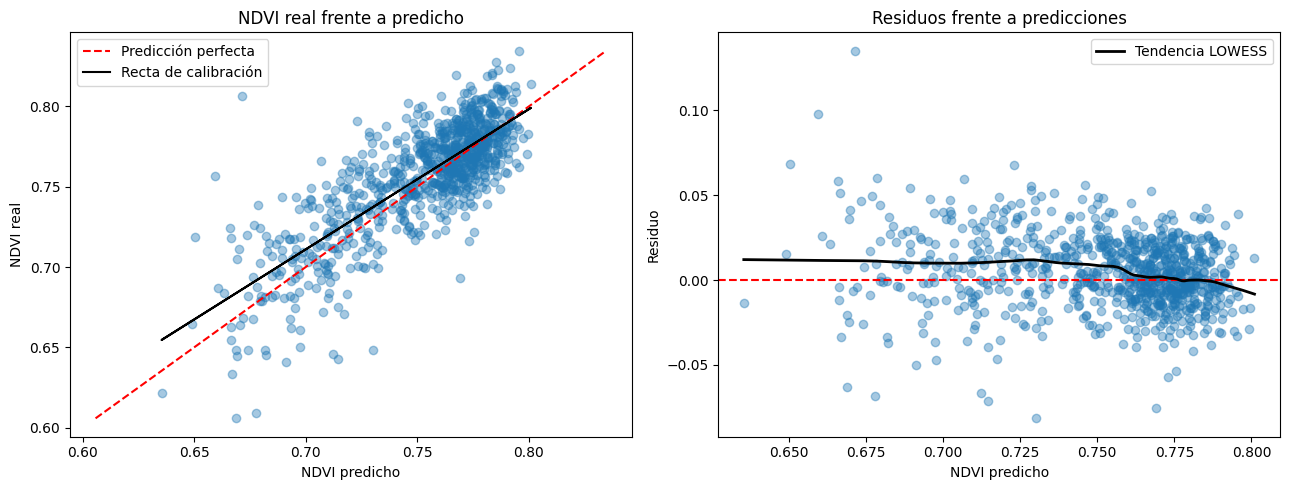

,r2_oof_global,pearson,pearson_p_value,intercepto_calibracion,pendiente_calibracion,spearman_residuo_prediccion,spearman_p_value,media_residuo
0,0.60354,0.795386,0.0,0.099937,0.872947,-0.200868,0.0,0.004386


In [8]:
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import r2_score

ndvi_real = diagnostico["ndvi_real"].to_numpy()
ndvi_predicho = diagnostico["ndvi_predicho"].to_numpy()
residuos = diagnostico["residuo"].to_numpy()

# Asociación lineal entre valor real y predicho
pearson_linealidad = stats.pearsonr(ndvi_real,ndvi_predicho)

# Tendencia monotónica entre predicción y residuo
spearman_residuos = stats.spearmanr(ndvi_predicho,residuos)

# Recta de calibración: NDVI real = intercepto + pendiente * predicción
calibracion = stats.linregress(ndvi_predicho,ndvi_real)

# Curva suavizada de los residuos
curva_lowess = lowess(endog=residuos, exog=ndvi_predicho, frac=0.25, return_sorted=True)

r2_oof_global = r2_score(ndvi_real, ndvi_predicho)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Real frente a predicho
axes[0].scatter(ndvi_predicho, ndvi_real, alpha=0.40)

limite_min = min(ndvi_predicho.min(), ndvi_real.min())

limite_max = max(ndvi_predicho.max(), ndvi_real.max())

axes[0].plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    color="red",
    linestyle="--",
    label="Predicción perfecta")

axes[0].plot(
    ndvi_predicho,
    calibracion.intercept
    + calibracion.slope * ndvi_predicho,
    color="black",
    label="Recta de calibración")

axes[0].set_title("NDVI real frente a predicho")
axes[0].set_xlabel("NDVI predicho")
axes[0].set_ylabel("NDVI real")
axes[0].legend()

# Residuos frente a predicción
axes[1].scatter(ndvi_predicho,residuos,alpha=0.40)

axes[1].axhline(0, color="red", linestyle="--")

axes[1].plot(curva_lowess[:, 0],curva_lowess[:, 1],color="black",linewidth=2,label="Tendencia LOWESS")

axes[1].set_title("Residuos frente a predicciones")
axes[1].set_xlabel("NDVI predicho")
axes[1].set_ylabel("Residuo")
axes[1].legend()

plt.tight_layout()
plt.show()

tabla_linealidad = pd.DataFrame([{
    "r2_oof_global": r2_oof_global,
    "pearson": pearson_linealidad.statistic,
    "pearson_p_value": pearson_linealidad.pvalue,
    "intercepto_calibracion": calibracion.intercept,
    "pendiente_calibracion": calibracion.slope,
    "spearman_residuo_prediccion": spearman_residuos.statistic,
    "spearman_p_value": spearman_residuos.pvalue,
    "media_residuo": residuos.mean()}])

display(tabla_linealidad.round(6))

La relación entre el NDVI real y el predicho es fuerte: Pearson es 0.795 y el R² OOF global es 0.6035. Sin embargo, este R² agrupa las 850 predicciones OOF, mientras que el R² anterior de aproximadamente 0.58 era el promedio de los cinco folds; no debemos sustituir uno por otro porque se calculan de forma diferente.

La línea de calibración está cerca de la predicción perfecta, pero la pendiente de 0.873, el residuo medio positivo de 0.0044 y la ligera tendencia descendente de los residuos muestran un pequeño sesgo: Ridge tiende a subestimar algunos valores bajos y medios y a sobreestimar ligeramente los más altos. El coeficiente de Spearman de −0.201 confirma que el patrón es débil. En conclusión, la linealidad está razonablemente satisfecha, aunque no de forma perfecta.

### homocedasticidad

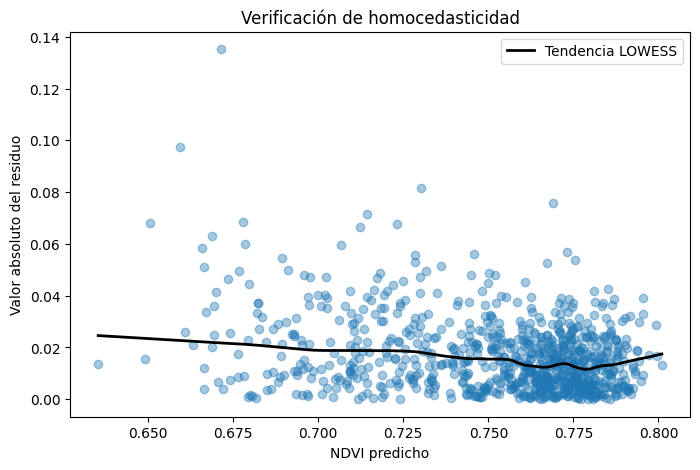

,breusch_pagan_lm,breusch_pagan_p_value,breusch_pagan_f,breusch_pagan_f_p_value,spearman_magnitud,spearman_p_value
0,70.014121,5.888144e-17,76.119294,1.397549e-17,-0.197743,6.093672e-09


Breusch-Pagan p-value: 5.888144e-17
Spearman p-value: 6.093672e-09


In [9]:
# Prueba de Breusch-Pagan
variables_bp = sm.add_constant(ndvi_predicho)

bp_lm, bp_p_value, bp_f, bp_f_p_value = het_breuschpagan(residuos, variables_bp)

# Asociación entre predicción y magnitud del error
spearman_magnitud = stats.spearmanr(ndvi_predicho, np.abs(residuos))

# Tendencia suavizada de la magnitud del error
curva_magnitud = lowess(endog=np.abs(residuos), exog=ndvi_predicho, frac=0.25, return_sorted=True)

plt.figure(figsize=(8, 5))

plt.scatter(ndvi_predicho, np.abs(residuos), alpha=0.40)

plt.plot(curva_magnitud[:, 0], curva_magnitud[:, 1], color="black", linewidth=2, label="Tendencia LOWESS")

plt.xlabel("NDVI predicho")
plt.ylabel("Valor absoluto del residuo")
plt.title("Verificación de homocedasticidad")
plt.legend()
plt.show()

tabla_homocedasticidad = pd.DataFrame([{
    "breusch_pagan_lm": bp_lm, "breusch_pagan_p_value": bp_p_value,
    "breusch_pagan_f": bp_f, "breusch_pagan_f_p_value": bp_f_p_value,
    "spearman_magnitud": spearman_magnitud.statistic, "spearman_p_value": spearman_magnitud.pvalue}])

display(tabla_homocedasticidad)

print("Breusch-Pagan p-value:", f"{bp_p_value:.6e}")

print("Spearman p-value:", f"{spearman_magnitud.pvalue:.6e}")

La prueba de Breusch–Pagan obtuvo \(p=5.89\times10^{-17}\), muy inferior a 0.05. Esto indica que la dispersión de los errores no es constante: hay más variabilidad en algunos niveles de NDVI que en otros. La gráfica muestra especialmente errores más grandes en los valores bajos y una reducción de su magnitud cuando aumenta la predicción.

Spearman fue −0.1977, lo que representa una relación débil: al aumentar el NDVI predicho, el tamaño del error tiende a disminuir ligeramente. Aunque la relación es pequeña, es estadísticamente significativa. Por tanto, se registra la homocedasticidad como no satisfecha. No obstante, aunque esto es una limitación, no obliga a descartar Ridge como modelo predictivo.

### normalidad y valores extremos

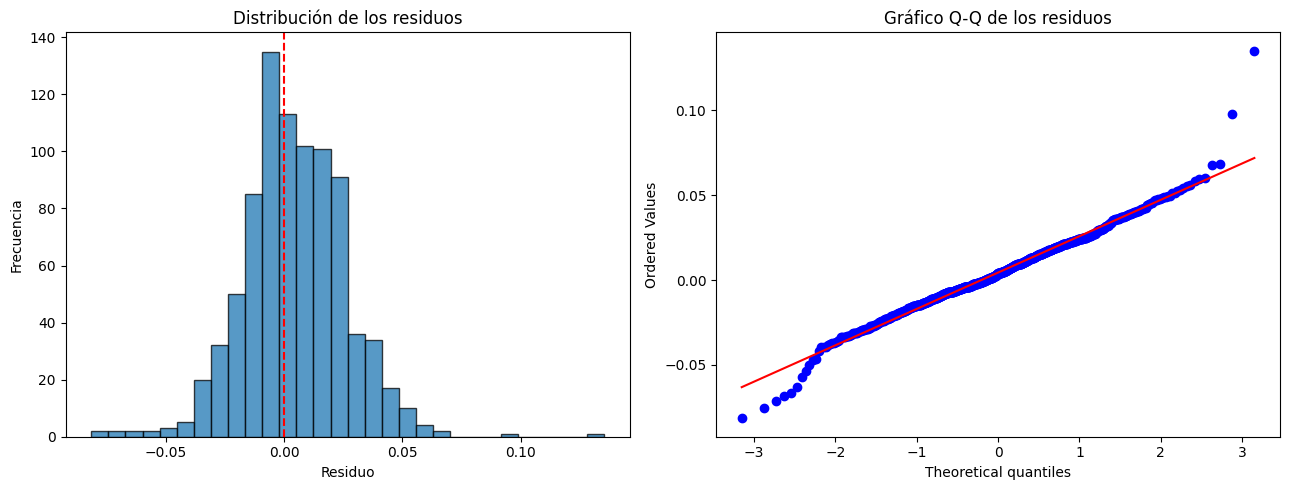

,jarque_bera,jarque_bera_p_value,asimetria,curtosis_exceso,observaciones_extremas,porcentaje_extremas
0,189.984492,5.564060e-42,0.190446,2.305255,8,0.941176


Jarque-Bera p-value: 5.564060e-42
Observaciones con |residuo estandarizado| > 3: 8
Porcentaje de observaciones extremas: 0.94%


In [10]:
# Prueba de normalidad Jarque-Bera
resultado_jb = stats.jarque_bera(residuos)

asimetria = stats.skew(residuos, bias=False)

curtosis_exceso = stats.kurtosis(residuos,fisher=True,bias=False)

# Valores extremos usando residuos estandarizados centrados
mascara_extremos = (diagnostico["residuo_estandarizado"]
    .abs()> 3)

cantidad_extremos = mascara_extremos.sum()

porcentaje_extremos = (
    100
    * cantidad_extremos
    / len(diagnostico))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma
axes[0].hist(residuos,bins=30,edgecolor="black",alpha=0.75)

axes[0].axvline(0,color="red",linestyle="--")

axes[0].set_title("Distribución de los residuos")
axes[0].set_xlabel("Residuo")
axes[0].set_ylabel("Frecuencia")

stats.probplot(residuos,dist="norm",plot=axes[1])

axes[1].set_title("Gráfico Q-Q de los residuos")

plt.tight_layout()
plt.show()

tabla_normalidad = pd.DataFrame([{
    "jarque_bera": resultado_jb.statistic,
    "jarque_bera_p_value": resultado_jb.pvalue,
    "asimetria": asimetria,
    "curtosis_exceso": curtosis_exceso,
    "observaciones_extremas": cantidad_extremos,
    "porcentaje_extremas": porcentaje_extremos}])

display(tabla_normalidad)

print("Jarque-Bera p-value:",f"{resultado_jb.pvalue:.6e}")

print("Observaciones con |residuo estandarizado| > 3:",cantidad_extremos)

print("Porcentaje de observaciones extremas:",f"{porcentaje_extremos:.2f}%")

La prueba de Jarque–Bera obtuvo \(p=5.56\times10^{-42}\), por lo que se rechaza la normalidad. Sin embargo, la asimetría es pequeña (0.19): los residuos son relativamente simétricos y la principal diferencia frente a una distribución normal está en sus colas, como muestra la curtosis de 2.31 y el gráfico Q-Q.

Solo 8 observaciones —0.94 %— tienen residuos estandarizados superiores a 3 en valor absoluto. Esta cantidad es reducida y no justifica eliminarlas automáticamente. Registraremos la normalidad como no satisfecha, pero esto no invalida el uso predictivo de Ridge; afecta principalmente la inferencia clásica sobre sus coeficientes. La diferencia frente a los 9 extremos anteriores se debe a que ahora los residuos fueron estandarizados correctamente restando su media.

### independencia temporal

In [11]:
resultados_independencia = []

for region, datos_region in diagnostico.groupby("region"):

    datos_region = (datos_region
        .sort_values("window_start")
        .copy())

    residuos_region = datos_region["residuo"].to_numpy()

    # Durbin-Watson
    estadistico_dw = durbin_watson(residuos_region)

    # Correlación directa entre residuos consecutivos
    autocorrelacion_lag1 = pd.Series(residuos_region).autocorr(lag=1)

    # Ljung-Box para 1, 3 y 6 periodos
    resultado_ljung = acorr_ljungbox(residuos_region,lags=[1, 3, 6],return_df=True)

    resultados_independencia.append({"region": region,"durbin_watson": estadistico_dw,"autocorrelacion_lag1": autocorrelacion_lag1,
        "ljung_box_p_lag1": resultado_ljung.loc[1, "lb_pvalue"],"ljung_box_p_lag3": resultado_ljung.loc[3, "lb_pvalue"],"ljung_box_p_lag6": resultado_ljung.loc[6, "lb_pvalue"]})

tabla_independencia = pd.DataFrame(resultados_independencia)

display(tabla_independencia)

for _, fila in tabla_independencia.iterrows():
    print(f"\nRegión: {fila['region']}")
    print("Durbin-Watson:",f"{fila['durbin_watson']:.6f}")
    print("Autocorrelación lag 1:",f"{fila['autocorrelacion_lag1']:.6f}")
    print("Ljung-Box p-value lag 1:",f"{fila['ljung_box_p_lag1']:.6e}")
    print("Ljung-Box p-value lag 3:", f"{fila['ljung_box_p_lag3']:.6e}")
    print("Ljung-Box p-value lag 6:",f"{fila['ljung_box_p_lag6']:.6e}")

,region,durbin_watson,autocorrelacion_lag1,ljung_box_p_lag1,ljung_box_p_lag3,ljung_box_p_lag6
0,Cauca,1.531031,0.204660,0.000025,5.248940e-13,3.038839e-11
1,Narino,1.926641,-0.016324,0.737021,1.765043e-01,3.917900e-01



Región: Cauca
Durbin-Watson: 1.531031
Autocorrelación lag 1: 0.204660
Ljung-Box p-value lag 1: 2.549119e-05
Ljung-Box p-value lag 3: 5.248940e-13
Ljung-Box p-value lag 6: 3.038839e-11

Región: Narino
Durbin-Watson: 1.926641
Autocorrelación lag 1: -0.016324
Ljung-Box p-value lag 1: 7.370212e-01
Ljung-Box p-value lag 3: 1.765043e-01
Ljung-Box p-value lag 6: 3.917900e-01


En Cauca, el supuesto de independencia temporal no se cumple: Durbin–Watson es 1.53, la autocorrelación de primer rezago es positiva (0.205) y las pruebas de Ljung–Box presentan valores p menores a 0.05 en los rezagos 1, 3 y 6. Esto indica que los errores cercanos en el tiempo conservan cierta relación y que el modelo no captura completamente la dinámica temporal de esta región.

En Nariño, el supuesto se cumple razonablemente: Durbin–Watson está cerca de 2 (1.93), la autocorrelación es prácticamente cero y todos los valores p de Ljung–Box son mayores a 0.05. Por lo tanto, registraremos la independencia temporal como parcialmente satisfecha y dependiente de la región. La validación temporal utilizada sigue siendo apropiada, pero la autocorrelación de Cauca debe mencionarse como limitación.

### preprocesamiento y multicolinealidad

In [12]:
# Verificación realizada únicamente con train_val.
# test_final continúa sin utilizarse.

imputador_revision = SimpleImputer(strategy="median")
escalador_revision = StandardScaler()

X_imputado_array = imputador_revision.fit_transform(X_ndvi)
X_escalado_array = escalador_revision.fit_transform(X_imputado_array)

X_imputado = pd.DataFrame(X_imputado_array,columns=X_ndvi.columns,index=X_ndvi.index)

X_escalado = pd.DataFrame(X_escalado_array,columns=X_ndvi.columns,index=X_ndvi.index)

# Calidad e imputación
calidad_registros = X_ndvi.notna().all(axis=1).mean()
faltantes_antes = int(X_ndvi.isna().sum().sum())
faltantes_despues = int(X_imputado.isna().sum().sum())

# Comprobación del escalamiento
media_maxima_abs = X_escalado.mean().abs().max()
std_minima = X_escalado.std(ddof=0).min()
std_maxima = X_escalado.std(ddof=0).max()

# Correlaciones altas entre variables
matriz_correlacion = X_imputado.corr()

triangulo_superior = matriz_correlacion.where(
    np.triu(np.ones(matriz_correlacion.shape),k=1).astype(bool))

pares_correlacion = (triangulo_superior
    .stack()
    .rename("correlacion")
    .reset_index()
    .rename(columns={"level_0": "variable_1","level_1": "variable_2"}))

pares_correlacion["correlacion_absoluta"] = (pares_correlacion["correlacion"].abs())

pares_altos = (pares_correlacion[pares_correlacion["correlacion_absoluta"] >= 0.90]
    .sort_values("correlacion_absoluta", ascending=False)
    .reset_index(drop=True))

# Rango y número de condición
valores_singulares = np.linalg.svd(X_escalado_array,compute_uv=False)

rango_matriz = np.linalg.matrix_rank(X_escalado_array)

if valores_singulares[-1] > 1e-12:
    numero_condicion = (
        valores_singulares[0] / valores_singulares[-1])
else:
    numero_condicion = np.inf

tabla_preprocesamiento = pd.DataFrame([{"filas": X_ndvi.shape[0],"variables": X_ndvi.shape[1],"calidad_registros": calidad_registros,
    "faltantes_antes_imputacion": faltantes_antes,"faltantes_despues_imputacion": faltantes_despues,"media_maxima_abs_escalada": media_maxima_abs,
    "std_minima_escalada": std_minima,"std_maxima_escalada": std_maxima,"rango_matriz": rango_matriz,"numero_condicion": numero_condicion,"pares_correlacion_abs_ge_090": len(pares_altos)}])

display(tabla_preprocesamiento)

print("\nPares con correlación absoluta >= 0.90:")
display(pares_altos.head(20))

,filas,variables,calidad_registros,faltantes_antes_imputacion,faltantes_despues_imputacion,media_maxima_abs_escalada,std_minima_escalada,std_maxima_escalada,rango_matriz,numero_condicion,pares_correlacion_abs_ge_090
0,1030,39,0.957282,88,0,5.325621e-15,1.0,1.0,36,inf,34



Pares con correlación absoluta >= 0.90:


,variable_1,variable_2,correlacion,correlacion_absoluta
0,region_Cauca,region_Narino,-1.000000,1.000000
1,precip_mm_lag0,deficit_hidrico,0.990718,0.990718
2,soil_moist_layer1_lag2,soil_moist_layer2_lag2,0.986558,0.986558
3,soil_moist_layer1_lag1,soil_moist_layer2_lag1,0.986532,0.986532
4,soil_moist_layer1_lag0,soil_moist_layer2_lag0,0.986519,0.986519
5,soil_moist_layer2_lag2,soil_moist_layer3_lag2,0.952597,0.952597
6,soil_moist_layer2_lag1,soil_moist_layer3_lag1,0.952371,0.952371
7,soil_moist_layer2_lag0,soil_moist_layer3_lag0,0.952356,0.952356
8,tmean_c_lag0,tmean_c_lag1,0.950492,0.950492
9,tmean_c_lag1,tmean_c_lag2,0.950404,0.950404


El preprocesamiento funcionó correctamente: el 95.73% de los registros está completo, superando la meta del 90%. Los 88 valores faltantes quedan resueltos mediante la imputación por mediana. Además, después del escalamiento, las variables tienen media prácticamente cero y desviación estándar igual a 1, que es lo esperado para Ridge.

Sí existe multicolinealidad alta: se encontraron 34 pares con correlación absoluta ≥ 0.90 y la matriz solo tiene rango 36 pese a contener 39 variables. El número de condición infinito confirma redundancias exactas; la más evidente es region_Cauca frente a region_Narino, porque una puede deducirse de la otra. Esto no invalida las predicciones de Ridge, ya que su regularización ayuda a controlar la multicolinealidad, pero sí dificulta interpretar cada coeficiente por separado. Por eso registraremos este supuesto como no satisfecho para interpretación de coeficientes, pero controlado parcialmente por Ridge.

### verificar orden temporal y ausencia de fuga

In [13]:
# Verificación del diseño temporal
fechas_revision = (pd.to_datetime(train_val["window_start"])
    .reset_index(drop=True))

revision_folds = []

for numero_fold, (idx_train, idx_val) in enumerate(cv_temporal,
    start=1):
    fechas_fold_train = fechas_revision.iloc[idx_train]
    fechas_fold_val = fechas_revision.iloc[idx_val]

    fechas_compartidas = set(fechas_fold_train).intersection(
        set(fechas_fold_val))

    indices_compartidos = set(idx_train).intersection(
        set(idx_val))

    revision_folds.append({"fold": numero_fold,"fecha_max_train": fechas_fold_train.max(),
        "fecha_min_validacion": fechas_fold_val.min(),"train_anterior_validacion": (fechas_fold_train.max()< fechas_fold_val.min()),
        "fechas_compartidas": len(fechas_compartidas),"indices_compartidos": len(indices_compartidos)})

tabla_revision_temporal = pd.DataFrame(revision_folds)

# Verificación de posibles variables con fuga
columnas_prohibidas = ["ndvi","evi","window_start","window_end"]

columnas_prohibidas_presentes = [
    columna
    for columna in columnas_prohibidas
    if columna in X_ndvi.columns]

maximo_indice_cv = max(
    max(np.max(idx_train), np.max(idx_val))
    for idx_train, idx_val in cv_temporal)

tabla_revision_general = pd.DataFrame([{
    "objetivo_es_numerico": pd.api.types.is_numeric_dtype(y_ndvi),
    "columnas_prohibidas_en_X": columnas_prohibidas_presentes,
    "cantidad_columnas_prohibidas": len(
        columnas_prohibidas_presentes),
    "cv_dentro_de_train_val": maximo_indice_cv < len(train_val),
    "fecha_max_train_val": pd.to_datetime(
        train_val["window_start"]).max(),
    "fecha_min_test_final": pd.to_datetime(
        test_final["window_start"]
    ).min(),
    "test_final_posterior": (
        pd.to_datetime(train_val["window_start"]).max()
        < pd.to_datetime(test_final["window_start"]).min())}])

display(tabla_revision_temporal)
display(tabla_revision_general)

,fold,fecha_max_train,fecha_min_validacion,train_anterior_validacion,fechas_compartidas,indices_compartidos
0,1,2004-02-02,2004-02-18,True,0,0
1,2,2007-10-16,2007-11-01,True,0,0
2,3,2011-06-26,2011-07-12,True,0,0
3,4,2015-03-06,2015-03-22,True,0,0
4,5,2018-11-17,2018-12-03,True,0,0


,objetivo_es_numerico,columnas_prohibidas_en_X,cantidad_columnas_prohibidas,cv_dentro_de_train_val,fecha_max_train_val,fecha_min_test_final,test_final_posterior
0,True,[],0,True,2022-07-28,2022-08-13,True


La validación temporal está correctamente construida. En los cinco folds, la última fecha de entrenamiento siempre ocurre antes de la primera fecha de validación y no existen fechas ni índices compartidos. Además, X_ndvi no contiene el NDVI actual, el EVI actual ni las fechas, por lo que no se detecta fuga directa de información.

También se confirma que toda la validación utiliza exclusivamente train_val, mientras que el conjunto final comienza después, el 13 de agosto de 2022. Por tanto, test_final permanece aislado y disponible para una evaluación final verdaderamente independiente. Este aspecto queda marcado como cumplido.

### tabla consolidada de supuestos

In [15]:
resumen_supuestos = pd.DataFrame([
    {"aspecto_evaluado": "Linealidad y calibración",
        "evidencia_principal": (
            "Pearson=0.795; R² OOF=0.604; "
            "pendiente de calibración=0.873"),
        "resultado": "Parcialmente cumplido",
        "interpretacion": (
            "Existe una relación lineal fuerte, aunque se observa "
            "una pequeña tendencia sistemática en los residuos.")},
    {"aspecto_evaluado": "Homocedasticidad",
        "evidencia_principal": (
            "Breusch-Pagan p<0.001; "
            "Spearman |residuo|-predicción=-0.198"),
        "resultado": "No cumplido",
        "interpretacion": (
            "La variabilidad de los errores cambia ligeramente "
            "según el nivel de NDVI predicho.")},
    {"aspecto_evaluado": "Normalidad de residuos",
        "evidencia_principal": (
            "Jarque-Bera p<0.001; curtosis=2.305; "
            "0.94% de observaciones extremas"
        ),
        "resultado": "No cumplido",
        "interpretacion": (
            "Los residuos presentan colas más pesadas que una "
            "distribución normal, aunque hay pocos casos extremos.")},
    {"aspecto_evaluado": "Independencia temporal",
        "evidencia_principal": (
            "Cauca: DW=1.531 y Ljung-Box p<0.001; "
            "Nariño: DW=1.927 y Ljung-Box p>0.05"),
        "resultado": "Parcialmente cumplido",
        "interpretacion": (
            "No se encontró autocorrelación en Nariño, pero sí "
            "dependencia temporal en los residuos de Cauca.")},
    {"aspecto_evaluado": "Multicolinealidad",
        "evidencia_principal": (
            "34 pares con |r|>=0.90; rango=36/39; "
            "número de condición infinito"),
        "resultado": "No cumplido, mitigado por Ridge",
        "interpretacion": (
            "Existen variables redundantes o muy relacionadas; "
            "la regularización de Ridge reduce su efecto.")},
    {"aspecto_evaluado": "Imputación y escalamiento",
        "evidencia_principal": (
            "88 faltantes antes y 0 después; "
            "medias≈0 y desviaciones=1"),
        "resultado": "Cumplido",
        "interpretacion": (
            "El preprocesamiento utilizado por el modelo funciona "
            "correctamente.")},
    {"aspecto_evaluado": "Calidad de los datos",
        "evidencia_principal": "95.73% de registros completos",
        "resultado": "Cumplido",
        "interpretacion": (
            "La calidad supera la meta mínima establecida del 90%."
        )},
    {"aspecto_evaluado": "Orden temporal y ausencia de fuga",
        "evidencia_principal": (
            "5 folds ordenados; 0 fechas o índices compartidos; "
            "test final posterior y separado"),
        "resultado": "Cumplido",
        "interpretacion": (
            "La evaluación respeta el orden temporal y mantiene "
            "aislado el conjunto de prueba final.")}])

pd.set_option("display.max_colwidth", None)
display(resumen_supuestos)

,aspecto_evaluado,evidencia_principal,resultado,interpretacion
0,Linealidad y calibración,Pearson=0.795; R² OOF=0.604; pendiente de calibración=0.873,Parcialmente cumplido,"Existe una relación lineal fuerte, aunque se observa una pequeña tendencia sistemática en los residuos."
1,Homocedasticidad,Breusch-Pagan p<0.001; Spearman |residuo|-predicción=-0.198,No cumplido,La variabilidad de los errores cambia ligeramente según el nivel de NDVI predicho.
2,Normalidad de residuos,Jarque-Bera p<0.001; curtosis=2.305; 0.94% de observaciones extremas,No cumplido,"Los residuos presentan colas más pesadas que una distribución normal, aunque hay pocos casos extremos."
3,Independencia temporal,Cauca: DW=1.531 y Ljung-Box p<0.001; Nariño: DW=1.927 y Ljung-Box p>0.05,Parcialmente cumplido,"No se encontró autocorrelación en Nariño, pero sí dependencia temporal en los residuos de Cauca."
4,Multicolinealidad,34 pares con |r|>=0.90; rango=36/39; número de condición infinito,"No cumplido, mitigado por Ridge",Existen variables redundantes o muy relacionadas; la regularización de Ridge reduce su efecto.
5,Imputación y escalamiento,88 faltantes antes y 0 después; medias≈0 y desviaciones=1,Cumplido,El preprocesamiento utilizado por el modelo funciona correctamente.
6,Calidad de los datos,95.73% de registros completos,Cumplido,La calidad supera la meta mínima establecida del 90%.
7,Orden temporal y ausencia de fuga,5 folds ordenados; 0 fechas o índices compartidos; test final posterior y separado,Cumplido,La evaluación respeta el orden temporal y mantiene aislado el conjunto de prueba final.


La verificación mostró que los supuestos clásicos de la regresión no se cumplen completamente. Se identificaron heterocedasticidad, residuos no normales, multicolinealidad y autocorrelación temporal en Cauca. No obstante, estas condiciones no invalidan automáticamente el uso predictivo de Ridge, debido a que la regularización reduce el efecto de la multicolinealidad y la evaluación se realizó mediante validación temporal sin fuga de información. Los resultados indican que el modelo puede utilizarse para predicción, pero sus coeficientes no deben interpretarse de manera causal y sus limitaciones deben considerarse al estimar la incertidumbre y al analizar resultados por región.